Стандартизация названий регионов...
Уникальных регионов после очистки: 85
МОДЕЛЬ XGBOOST ДЛЯ ПРОГНОЗА ОПЖ
Обучение: 2014-2021, Валидация: 2022-2023
Прогнозы: 2019, 2023 (сравнение), 2024, 2025 (будущие)

ДИАГНОСТИКА ДАННЫХ:
Размер данных: (850, 17)
Период данных: 2014-2023
Количество регионов: 85
Доступные годы: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]

ОБУЧЕНИЕ МОДЕЛИ XGBOOST
Данные за период: 2014-2023
Используется 33 признаков
Размер train: (680, 33), test: (170, 33)
Период обучения: 2014-2021
Период тестирования: 2022-2023
Обучение модели XGBoost...

МЕТРИКИ КАЧЕСТВА ТЕСТ (2022-2023)
RMSE: 1.6475 лет
MAE: 1.5756 лет
R²: 0.5668
MAPE: 2.18%
Средняя реальная ОПЖ: 72.11 лет
Средняя прогнозная ОПЖ: 70.54 лет
Средняя абсолютная ошибка: 1.5756 лет
Максимальная ошибка: 3.0338 лет
Минимальная ошибка: 0.1753 лет

Кросс-валидация (RMSE):
Среднее: 0.4172 (+/- 0.2400)

1. ПРОГ

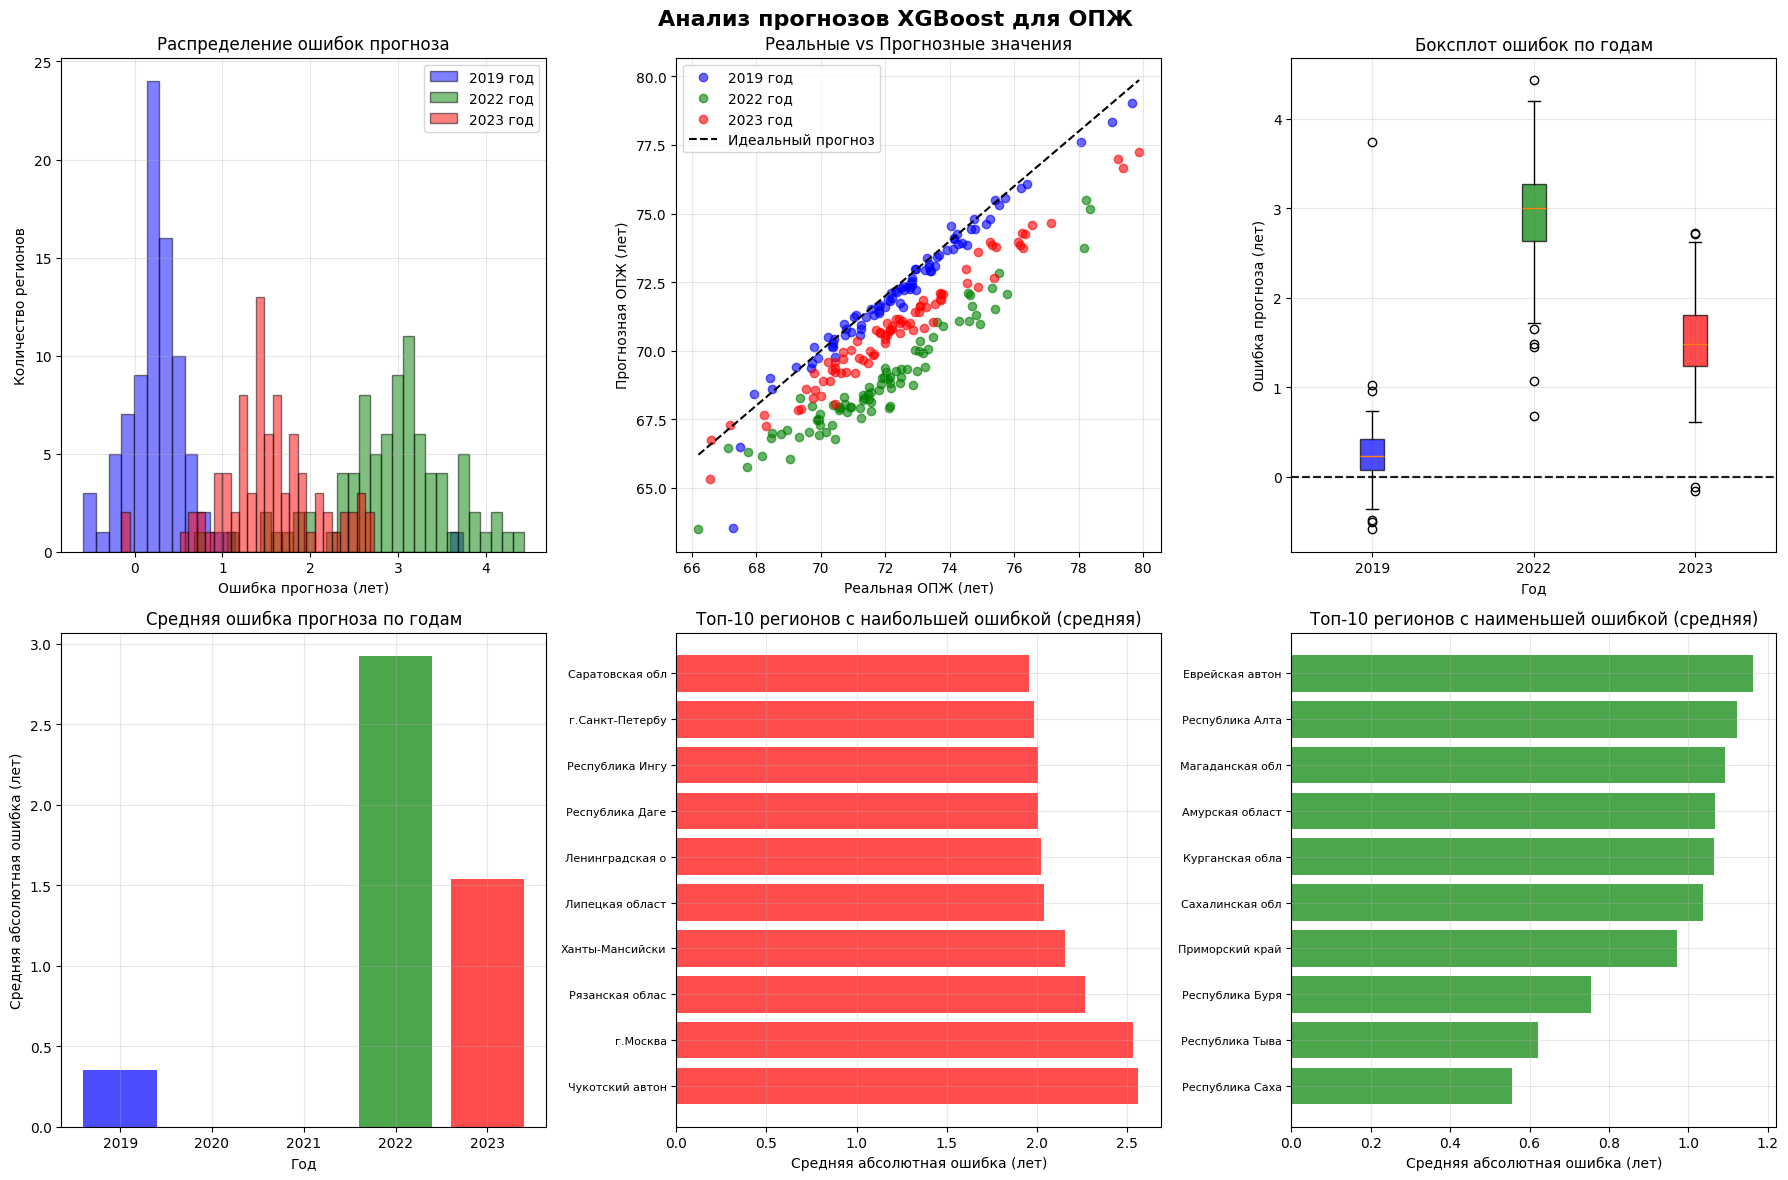


4. ПРОГНОЗ НА БУДУЩИЕ ГОДЫ (2024, 2025)

ПРОГНОЗ НА БУДУЩИЕ ПЕРИОДЫ

Прогноз успешно создан для годов: [2024, 2025]
Средняя прогнозная ОПЖ на 2025 год: 70.97 лет
Минимальная ОПЖ: 65.42 лет
Максимальная ОПЖ: 76.42 лет
✓ Прогнозы сохранены в 'c:\Users\HUAWEI\PycharmProjects\pythonProject\demography_forecast_rf\DataAndMopdels\notebooks\XGBoost\predictions_ele_2025.xlsx'

ДЕТАЛЬНЫЙ АНАЛИЗ ПРОГНОЗА НА 2025 ГОД
Средняя прогнозная ОПЖ: 70.97 лет
Минимальная ОПЖ: 65.42 лет
Максимальная ОПЖ: 76.42 лет
Стандартное отклонение: 2.36 лет

ТОП-5 РЕГИОНОВ С НАИБОЛЬШЕЙ ОПЖ В 2025 ГОДУ:
  Республика Дагестан            | ОПЖ: 76.42 лет | Изменение с 2023: -1.07 лет
  Республика Ингушетия           | ОПЖ: 76.29 лет | Изменение с 2023: -1.25 лет
  г.Москва                       | ОПЖ: 76.02 лет | Изменение с 2023: -1.22 лет
  Кабардино-Балкарская Республик | ОПЖ: 75.49 лет | Изменение с 2023: -0.64 лет
  Ханты-Мансийский автономный ок | ОПЖ: 74.59 лет | Изменение с 2023: -0.78 лет

ТОП-5 РЕГИОНОВ С НАИМ

In [3]:
# XGBoost для ОПЖ с данными за 2014-2023 и прогнозами на 2019, 2023, 2025
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import joblib
import os
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    current_dir = os.getcwd()

output_dir = current_dir

def standardize_region_names(df):
    """Стандартизация названий регионов"""
    df_clean = df.copy()
    # Создаем словарь замен
    replacements = {
        'Ненецкий авт.округ': 'Ненецкий автономный округ',
        'Hенецкий авт.округ': 'Ненецкий автономный округ',
        '  Ненецкий автономный округ': 'Ненецкий автономный округ',
        
        'Ямало-Ненецкий авт.округ': 'Ямало-Ненецкий автономный округ',
        'Ямало-Hенецкий авт.округ': 'Ямало-Ненецкий автономный округ',
        '  Ямало-Ненецкий автономный округ': 'Ямало-Ненецкий автономный округ',
        
        'Ханты-Мансийский авт.округ-Югра': 'Ханты-Мансийский автономный округ - Югра',
        '  Ханты-Мансийский автономный округ - Югра': 'Ханты-Мансийский автономный округ - Югра',
        
        'Республика Татарстан(Татарстан)': 'Республика Татарстан',
        'Чувашская Республика(Чувашия)': 'Чувашская Республика',
        'Республика Северная Осетия- Алания': 'Республика Северная Осетия-Алания',
        
        'Oмская область': 'Омская область',
        'Hижегородская область': 'Нижегородская область',
        
        'г. Севастополь': 'г.Севастополь',
        'г.Москва': 'г.Москва',
        'г.Санкт-Петербург': 'г.Санкт-Петербург',
        
        'Чукотский авт.округ': 'Чукотский автономный округ',
        'Чукотский автономный округ': 'Чукотский автономный округ'
    }

    # Применяем замены
    df_clean['Регион'] = df_clean['Регион'].replace(replacements)

    return df_clean

class OPJXGBoostForecaster:
    def __init__(self, random_state=42):
        self.model = xgb.XGBRegressor(
            max_depth=6,
            learning_rate=0.03,
            n_estimators=400,
            random_state=random_state,
            n_jobs=-1,
            subsample=0.7,
            colsample_bytree=0.7,
            reg_alpha=0.1,
            reg_lambda=1.0
        )
        self.scaler = StandardScaler()
        self.feature_names = []
        self.is_fitted = False
        self.first_year = None
        self.last_known_data_2018 = None
        self.last_known_data_2022 = None
        self.last_known_data_2023 = None
        self.comparison_results_2019 = None
        self.comparison_results_2023 = None

    def clean_numeric_columns(self, df):
        """
        Очистка числовых колонок
        """
        df = df.copy()
        
        numeric_columns = [col for col in df.columns if col not in ['Регион', 'Год', 'ОПЖ']]
        
        for col in numeric_columns:
            if df[col].dtype == 'object':
                df[col] = (df[col]
                          .astype(str)
                          .str.replace('\xa0', '')
                          .str.replace(' ', '')
                          .str.replace(',', '.')
                          .str.replace('−', '-')
                          .str.replace('–', '-')
                          )
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        if 'ОПЖ' in df.columns:
            df['ОПЖ'] = pd.to_numeric(df['ОПЖ'], errors='coerce')
        
        return df
    
    def prepare_features(self, df, is_training=True):
        """
        Подготовка признаков для ОПЖ
        """
        df = df.copy().sort_values(['Регион', 'Год'])
        
        # Определяем первый год для расчета тренда
        if self.first_year is None:
            self.first_year = df['Год'].min()
        
        # Создание лаговых признаков
        df['lag1_ОПЖ'] = df.groupby('Регион')['ОПЖ'].shift(1)
        df['lag2_ОПЖ'] = df.groupby('Регион')['ОПЖ'].shift(2)
        df['lag1_Число умерших'] = df.groupby('Регион')['Число умерших'].shift(1)
        df['lag1_Младенческая смертность коэф'] = df.groupby('Регион')['Младенческая смертность коэф'].shift(1)
        df['lag1_Общая численность инвалидов'] = df.groupby('Регион')['Общая численность инвалидов'].shift(1)
        
        # Скользящие средние
        df['ОПЖ_MA2'] = df.groupby('Регион')['ОПЖ'].transform(lambda x: x.rolling(2, min_periods=1).mean())
        df['ОПЖ_MA3'] = df.groupby('Регион')['ОПЖ'].transform(lambda x: x.rolling(3, min_periods=1).mean())
        
        # Создание тренда времени
        df['year_trend'] = df['Год'] - self.first_year
        df['год_от_начала'] = df['Год'] - self.first_year
    
        # Создание производных медицинских и социальных показателей
        df['Врачей_на_10k'] = df['Численность врачей всех специальностей'] / df['Численность населения'] * 10000
        df['Умерших_на_1000'] = df['Число умерших'] / df['Численность населения'] * 1000
        df['Инвалидов_на_1000'] = df['Общая численность инвалидов'] / df['Численность населения'] * 1000
        df['Преступлений_на_1000'] = df['Кол-во преступлений'] / df['Численность населения'] * 1000
        df['Браков_на_1000'] = df['Браков'] / df['Численность населения'] * 1000
        df['Разводов_на_1000'] = df['Разводов'] / df['Численность населения'] * 1000
        
        # Индексы развития
        df['Индекс_здравоохранения'] = (
            df['Врачей_на_10k'] + 
            df['Число больничных организаций на конец отчетного года'] + 
            df['Число санаторно-курортных организаций']
        ) / 3
        
        df['Социальный_индекс'] = (
            df['Средняя ЗП'] / df['Величина прожиточного минимума'] - 
            (df['Уровень бедности'] / 100)
        )
    
        # Относительные изменения
        df['изменение_населения'] = df.groupby('Регион')['Численность населения'].pct_change()
        df['изменение_ВРП'] = df.groupby('Регион')['Валовой региональный продукт на душу населения (ОКВЭД 2)'].pct_change()
        
        if is_training:
            # Заполняем числовые колонки медианами по регионам
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            for col in numeric_cols:
                if col not in ['Год']:
                    df[col] = df.groupby('Регион')[col].transform(
                        lambda x: x.fillna(x.median()) if not x.isnull().all() else x
                    )
            
            # Если все еще есть NaN, заполняем общими медианами
            df = df.fillna(df.median(numeric_only=True))
        
        return df

    def train_test_split_temporal(self, df, test_years):
        """
        Разделение на train/test по времени
        """
        train_mask = ~df['Год'].isin(test_years)
        test_mask = df['Год'].isin(test_years)
        
        X_train = df[train_mask][self.feature_names]
        X_test = df[test_mask][self.feature_names]
        y_train = df[train_mask]['ОПЖ']
        y_test = df[test_mask]['ОПЖ']
        
        return X_train, X_test, y_train, y_test, train_mask, test_mask

    def fit(self, df, test_years=[2022, 2023]):
        """
        Обучение модели для ОПЖ (обучение: 2014-2021, тест: 2022-2023)
        """
        # Очистка и подготовка данных
        df_clean = self.clean_numeric_columns(df)
        df_processed = self.prepare_features(df_clean, is_training=True)
        
        print(f"Данные за период: {df_processed['Год'].min()}-{df_processed['Год'].max()}")
        
        # Сохраняем данные за нужные годы для прогнозов
        self.last_known_data_2018 = df_processed[df_processed['Год'] == 2018].copy()
        self.last_known_data_2022 = df_processed[df_processed['Год'] == 2022].copy()
        self.last_known_data_2023 = df_processed[df_processed['Год'] == 2023].copy()
        
        # Определение признаков для ОПЖ
        self.feature_names = [
            # Базовые демографические
            'Численность населения', 
            'Число умерших', 
            'Общая численность инвалидов',
            'Браков',
            'Разводов',
        
            # Медицинские факторы
            'Младенческая смертность коэф', 
            'Численность врачей всех специальностей', 
            'Число больничных организаций на конец отчетного года', 
            'Число санаторно-курортных организаций',
            
            # Социально-экономические
            'Валовой региональный продукт на душу населения (ОКВЭД 2)',
            'Величина прожиточного минимума', 
            'Уровень бедности', 
            'Средняя ЗП',
            'Кол-во преступлений',
            
            # Лаговые признаки
            'lag1_ОПЖ', 
            'lag2_ОПЖ',
            'lag1_Число умерших', 
            'lag1_Младенческая смертность коэф', 
            'lag1_Общая численность инвалидов',
            
            # Скользящие средние
            'ОПЖ_MA2',
            'ОПЖ_MA3',
        
            # Тренд и время
            'year_trend',
            'год_от_начала',
            
            # Производные показатели
            'Врачей_на_10k', 
            'Умерших_на_1000', 
            'Инвалидов_на_1000', 
            'Преступлений_на_1000',
            'Браков_на_1000',
            'Разводов_на_1000',
            'Индекс_здравоохранения', 
            'Социальный_индекс',
            'изменение_населения',
            'изменение_ВРП'
        ]
    
        # Убираем признаки, которых нет в данных
        available_features = [f for f in self.feature_names if f in df_processed.columns]
        self.feature_names = available_features
        
        print(f"Используется {len(self.feature_names)} признаков")
        
        # Разделение на train/test
        X_train, X_test, y_train, y_test, train_mask, test_mask = self.train_test_split_temporal(df_processed, test_years)
        
        print(f"Размер train: {X_train.shape}, test: {X_test.shape}")
        print(f"Период обучения: {df_processed[train_mask]['Год'].min()}-{df_processed[train_mask]['Год'].max()}")
        print(f"Период тестирования: {df_processed[test_mask]['Год'].min()}-{df_processed[test_mask]['Год'].max()}")
        
        # Масштабирование признаков
        scale_features = [f for f in self.feature_names if not f.startswith(('lag', 'ОПЖ_MA', 'изменение_'))]
        X_train_scaled = X_train.copy()
        X_test_scaled = X_test.copy()
        
        X_train_scaled[scale_features] = self.scaler.fit_transform(X_train[scale_features])
        X_test_scaled[scale_features] = self.scaler.transform(X_test[scale_features])
        
        # Обучение модели
        print("Обучение модели XGBoost...")
        self.model.fit(X_train_scaled, y_train)
        self.is_fitted = True
    
        # Предсказание на тесте
        y_pred = self.model.predict(X_test_scaled)
        
        # Метрики качества на тесте
        self.calculate_metrics(y_test, y_pred, "ТЕСТ (2022-2023)")
        
        # Дополнительная валидация
        self.cross_validation(X_train_scaled, y_train)
        
        # Сохранение результатов
        self.results = {
            'X_train': X_train_scaled, 'X_test': X_test_scaled,
            'y_train': y_train, 'y_test': y_test, 'y_pred': y_pred,
            'df_processed': df_processed,
            'test_years': test_years
        }
        
        return self

    def calculate_metrics(self, y_true, y_pred, title=""):
        """
        Расчет метрик качества для ОПЖ
        """
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        
        # ДОБАВЛЕНО: Максимальная и минимальная ошибка
        max_error = np.max(np.abs(y_true - y_pred))
        min_error = np.min(np.abs(y_true - y_pred))
        
        print(f"\nМЕТРИКИ КАЧЕСТВА {title}")
        print("="*50)
        print(f"RMSE: {rmse:.4f} лет")
        print(f"MAE: {mae:.4f} лет")
        print(f"R²: {r2:.4f}")
        print(f"MAPE: {mape:.2f}%")
        print(f"Средняя реальная ОПЖ: {y_true.mean():.2f} лет")
        print(f"Средняя прогнозная ОПЖ: {y_pred.mean():.2f} лет")
        print(f"Средняя абсолютная ошибка: {np.mean(np.abs(y_true - y_pred)):.4f} лет")
        print(f"Максимальная ошибка: {max_error:.4f} лет")  # ДОБАВЛЕНО
        print(f"Минимальная ошибка: {min_error:.4f} лет")   # ДОБАВЛЕНО
        
        return {
            'RMSE': rmse, 
            'MAE': mae, 
            'R2': r2, 
            'MAPE': mape,
            'Max_Error': max_error,
            'Min_Error': min_error
        }

    def cross_validation(self, X_train, y_train, cv=5):
        """
        Кросс-валидация для оценки устойчивости модели
        """
        print("\nКросс-валидация (RMSE):")
        temp_model = xgb.XGBRegressor(
            max_depth=6,
            learning_rate=0.03,
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
        
        scores = cross_val_score(temp_model, X_train, y_train, 
                               scoring='neg_mean_squared_error', cv=cv)
        rmse_scores = np.sqrt(-scores)
        print(f"Среднее: {rmse_scores.mean():.4f} (+/- {rmse_scores.std() * 2:.4f})")

    def predict_and_compare(self, df, target_year, last_known_data, last_known_year):
        """
        Прогноз ОПЖ на указанный год и сравнение с реальными значениями
        """
        if not self.is_fitted:
            print("Сначала обучите модель!")
            return None, None
        
        print(f"\n{'='*70}")
        print(f"ПРОГНОЗ НА {target_year} ГОД И СРАВНЕНИЕ С РЕАЛЬНЫМИ ДАННЫМИ")
        print(f"{'='*70}")
        
        # Получаем реальные значения за target_year
        real_data = df[df['Год'] == target_year][['Регион', 'ОПЖ']].copy()
        real_data = real_data.rename(columns={'ОПЖ': 'ОПЖ_реальный'})
        
        all_predictions = []
    
        for _, last_row in last_known_data.iterrows():
            # Создаем строку для прогноза
            future_row = last_row.copy()
            future_row['Год'] = target_year
            future_row['year_trend'] = target_year - self.first_year
            future_row['год_от_начала'] = target_year - self.first_year
            
            # Прогноз основных показателей
            years_diff = target_year - last_known_year
            
            # Прогноз с умеренным ростом
            future_row['Численность населения'] = last_row['Численность населения'] * (1.002 ** years_diff)
            future_row['Число умерших'] = last_row['Число умерших'] * (0.995 ** years_diff)
            future_row['Общая численность инвалидов'] = last_row['Общая численность инвалидов']
            future_row['Младенческая смертность коэф'] = last_row['Младенческая смертность коэф'] * (0.98 ** years_diff)
            future_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] = last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] * (1.015 ** years_diff)
            future_row['Средняя ЗП'] = last_row['Средняя ЗП'] * (1.03 ** years_diff)
            future_row['Численность врачей всех специальностей'] = last_row['Численность врачей всех специальностей'] * (1.01 ** years_diff)
            future_row['Величина прожиточного минимума'] = last_row['Величина прожиточного минимума'] * (1.02 ** years_diff)
            future_row['Уровень бедности'] = last_row['Уровень бедности'] * (0.99 ** years_diff)
            future_row['Браков'] = last_row['Браков'] * (1.005 ** years_diff)
            future_row['Разводов'] = last_row['Разводов'] * (1.003 ** years_diff)
            future_row['Кол-во преступлений'] = last_row['Кол-во преступлений'] * (0.99 ** years_diff)
            
            # Лаги берем из последнего известного года
            future_row['lag1_ОПЖ'] = last_row['ОПЖ']
            future_row['lag2_ОПЖ'] = last_row['lag1_ОПЖ']
            future_row['lag1_Число умерших'] = last_row['Число умерших']
            future_row['lag1_Младенческая смертность коэф'] = last_row['Младенческая смертность коэф']
            future_row['lag1_Общая численность инвалидов'] = last_row['Общая численность инвалидов']
        
            # Пересчитываем скользящие средние
            future_row['ОПЖ_MA2'] = (future_row['lag1_ОПЖ'] + last_row['ОПЖ']) / 2
            future_row['ОПЖ_MA3'] = (future_row['lag2_ОПЖ'] + future_row['lag1_ОПЖ'] + last_row['ОПЖ']) / 3
            
            # Пересчитываем производные показатели
            future_row['Врачей_на_10k'] = future_row['Численность врачей всех специальностей'] / future_row['Численность населения'] * 10000
            future_row['Умерших_на_1000'] = future_row['Число умерших'] / future_row['Численность населения'] * 1000
            future_row['Инвалидов_на_1000'] = future_row['Общая численность инвалидов'] / future_row['Численность населения'] * 1000
            future_row['Преступлений_на_1000'] = future_row['Кол-во преступлений'] / future_row['Численность населения'] * 1000
            future_row['Браков_на_1000'] = future_row['Браков'] / future_row['Численность населения'] * 1000
            future_row['Разводов_на_1000'] = future_row['Разводов'] / future_row['Численность населения'] * 1000
            
            future_row['Индекс_здравоохранения'] = (
                future_row['Врачей_на_10k'] + 
                future_row['Число больничных организаций на конец отчетного года'] + 
                future_row['Число санаторно-курортных организаций']
            ) / 3
            
            future_row['Социальный_индекс'] = (
                future_row['Средняя ЗП'] / future_row['Величина прожиточного минимума'] - 
                (future_row['Уровень бедности'] / 100)
            )
        
            future_row['изменение_населения'] = (future_row['Численность населения'] - last_row['Численность населения']) / last_row['Численность населения']
            future_row['изменение_ВРП'] = (future_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] - last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']) / last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']
            
            all_predictions.append(future_row)
    
        # Создаем DataFrame для прогноза
        future_df = pd.DataFrame(all_predictions)
        X_future = future_df[self.feature_names]
        
        # Масштабирование
        scale_features = [f for f in self.feature_names if not f.startswith(('lag', 'ОПЖ_MA', 'изменение_'))]
        X_future_scaled = X_future.copy()
        X_future_scaled[scale_features] = self.scaler.transform(X_future[scale_features])
        
        # Прогноз ОПЖ
        predictions = self.model.predict(X_future_scaled)
    
        # Собираем результаты
        results = []
        for i, (_, last_row) in enumerate(last_known_data.iterrows()):
            results.append({
                'Регион': last_row['Регион'],
                'Год': target_year,
                'ОПЖ_прогноз': predictions[i],
                f'ОПЖ_{last_known_year}': last_row['ОПЖ']
            })
        
        results_df = pd.DataFrame(results)
    
        # Объединяем с реальными значениями
        comparison_df = pd.merge(results_df, real_data, on='Регион', how='inner')
        
        # Рассчитываем ошибки
        comparison_df['Ошибка_абсолютная'] = comparison_df['ОПЖ_реальный'] - comparison_df['ОПЖ_прогноз']
        comparison_df['Ошибка_абсолютная_abs'] = np.abs(comparison_df['Ошибка_абсолютная'])
        comparison_df['Ошибка_относительная_%'] = (comparison_df['Ошибка_абсолютная'] / comparison_df['ОПЖ_реальный']) * 100
        
        # Рассчитываем метрики
        metrics = self.calculate_metrics(
            comparison_df['ОПЖ_реальный'], 
            comparison_df['ОПЖ_прогноз'],
            f"ПРОГНОЗ НА {target_year} ГОД"
        )
        
        # Анализ результатов
        self.analyze_comparison_results(comparison_df, target_year)
        
        return comparison_df, metrics

    def analyze_comparison_results(self, comparison_df, target_year):
        """
        Детальный анализ результатов сравнения
        """
        print(f"\n{'='*70}")
        print(f"ДЕТАЛЬНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ ДЛЯ {target_year} ГОДА")
        print(f"{'='*70}")
        
        print(f"\nОБЩАЯ СТАТИСТИКА:")
        print(f"Всего регионов: {len(comparison_df)}")
        print(f"Средняя реальная ОПЖ: {comparison_df['ОПЖ_реальный'].mean():.2f} лет")
        print(f"Средняя прогнозная ОПЖ: {comparison_df['ОПЖ_прогноз'].mean():.2f} лет")
        print(f"Средняя абсолютная ошибка: {comparison_df['Ошибка_абсолютная_abs'].mean():.3f} лет")
        print(f"Медианная абсолютная ошибка: {comparison_df['Ошибка_абсолютная_abs'].median():.3f} лет")
        
        # ДОБАВЛЕНО: Максимальная и минимальная ошибка
        print(f"Максимальная ошибка: {comparison_df['Ошибка_абсолютная_abs'].max():.3f} лет")
        print(f"Минимальная ошибка: {comparison_df['Ошибка_абсолютная_abs'].min():.3f} лет")
        
        # Топ регионов с максимальной положительной ошибкой (прогноз занижен)
        max_positive_error = comparison_df[comparison_df['Ошибка_абсолютная'] > 0]['Ошибка_абсолютная_abs'].max()
        if pd.notna(max_positive_error):
            max_positive_region = comparison_df[comparison_df['Ошибка_абсолютная_abs'] == max_positive_error].iloc[0]
            print(f"\nНАИБОЛЬШАЯ ПОЛОЖИТЕЛЬНАЯ ОШИБКА (прогноз занижен):")
            print(f"  {max_positive_region['Регион'][:30]:<30} | Ошибка: {max_positive_error:.3f} лет | "
                  f"Реальный: {max_positive_region['ОПЖ_реальный']:.2f} | Прогноз: {max_positive_region['ОПЖ_прогноз']:.2f}")
        
        # Топ регионов с максимальной отрицательной ошибкой (прогноз завышен)
        max_negative_error = comparison_df[comparison_df['Ошибка_абсолютная'] < 0]['Ошибка_абсолютная_abs'].max()
        if pd.notna(max_negative_error):
            max_negative_region = comparison_df[comparison_df['Ошибка_абсолютная_abs'] == max_negative_error].iloc[0]
            print(f"\nНАИБОЛЬШАЯ ОТРИЦАТЕЛЬНАЯ ОШИБКА (прогноз завышен):")
            print(f"  {max_negative_region['Регион'][:30]:<30} | Ошибка: {max_negative_error:.3f} лет | "
                  f"Реальный: {max_negative_region['ОПЖ_реальный']:.2f} | Прогноз: {max_negative_region['ОПЖ_прогноз']:.2f}")
        
        # 3 лучших предсказания
        print(f"\nТОП-3 РЕГИОНА С НАИЛУЧШИМ ПРОГНОЗОМ:")
        top_accurate = comparison_df.nsmallest(3, 'Ошибка_абсолютная_abs')
        for i, row in top_accurate.iterrows():
            print(f"  {row['Регион'][:30]:<30} | Ошибка: {row['Ошибка_абсолютная_abs']:.3f} лет | "
                  f"Реальный: {row['ОПЖ_реальный']:.2f} | Прогноз: {row['ОПЖ_прогноз']:.2f}")
        
        # 3 худших предсказания
        print(f"\nТОП-3 РЕГИОНА С НАИХУДШИМ ПРОГНОЗОМ:")
        top_error = comparison_df.nlargest(3, 'Ошибка_абсолютная_abs')
        for i, row in top_error.iterrows():
            print(f"  {row['Регион'][:30]:<30} | Ошибка: {row['Ошибка_абсолютная_abs']:.3f} лет | "
                  f"Реальный: {row['ОПЖ_реальный']:.2f} | Прогноз: {row['ОПЖ_прогноз']:.2f}")
        
        # Статистика по знакам ошибок
        positive_errors = (comparison_df['Ошибка_абсолютная'] > 0).sum()
        negative_errors = (comparison_df['Ошибка_абсолютная'] < 0).sum()
        zero_errors = (comparison_df['Ошибка_абсолютная'] == 0).sum()
        
        print(f"\nРАСПРЕДЕЛЕНИЕ ОШИБОК ПО ЗНАКУ:")
        print(f"Прогноз занижен (реальный > прогноз): {positive_errors} регионов")
        print(f"Прогноз завышен (реальный < прогноз): {negative_errors} регионов")
        print(f"Точное совпадение: {zero_errors} регионов")
        
        # Средняя ошибка по знакам
        if positive_errors > 0:
            avg_positive_error = comparison_df[comparison_df['Ошибка_абсолютная'] > 0]['Ошибка_абсолютная'].mean()
            print(f"Средняя положительная ошибка: {avg_positive_error:.3f} лет")
        if negative_errors > 0:
            avg_negative_error = comparison_df[comparison_df['Ошибка_абсолютная'] < 0]['Ошибка_абсолютная'].mean()
            print(f"Средняя отрицательная ошибка: {avg_negative_error:.3f} лет")
        
        return comparison_df

    def create_comparison_plots(self, comparison_dfs, years):
        """
        Создание 6 графиков на одной картинке
        """
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Анализ прогнозов XGBoost для ОПЖ', fontsize=16, fontweight='bold')
        
        colors = ['blue', 'green', 'red', 'orange']
        
        for idx, (comparison_df, year, color) in enumerate(zip(comparison_dfs, years, colors[:len(comparison_dfs)])):
            # График 1: Распределение ошибок
            axes[0, 0].hist(comparison_df['Ошибка_абсолютная'], bins=30, 
                          alpha=0.5, label=f'{year} год', color=color, edgecolor='black')
            axes[0, 0].set_xlabel('Ошибка прогноза (лет)')
            axes[0, 0].set_ylabel('Количество регионов')
            axes[0, 0].set_title('Распределение ошибок прогноза')
            axes[0, 0].legend()
            axes[0, 0].grid(True, alpha=0.3)
            
            # График 2: Реальные vs прогнозные значения
            axes[0, 1].scatter(comparison_df['ОПЖ_реальный'], comparison_df['ОПЖ_прогноз'], 
                             alpha=0.6, label=f'{year} год', color=color)
            axes[0, 1].set_xlabel('Реальная ОПЖ (лет)')
            axes[0, 1].set_ylabel('Прогнозная ОПЖ (лет)')
            axes[0, 1].set_title('Реальные vs Прогнозные значения')
            axes[0, 1].grid(True, alpha=0.3)
        
            # График 3: Боксплот ошибок
            positions = [idx + 1]
            axes[0, 2].boxplot([comparison_df['Ошибка_абсолютная']], positions=positions, 
                             patch_artist=True, boxprops=dict(facecolor=color, alpha=0.7))
            axes[0, 2].set_xlabel('Год')
            axes[0, 2].set_ylabel('Ошибка прогноза (лет)')
            axes[0, 2].set_title('Боксплот ошибок по годам')
            axes[0, 2].set_xticks(range(1, len(years) + 1))
            axes[0, 2].set_xticklabels(years)
            axes[0, 2].grid(True, alpha=0.3)
            axes[0, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        
        # Линия идеального прогноза для графика 2
        all_real = np.concatenate([df['ОПЖ_реальный'] for df in comparison_dfs])
        min_val, max_val = all_real.min(), all_real.max()
        axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'k--', label='Идеальный прогноз')
        axes[0, 1].legend()
    
        # График 4: Средняя ошибка по годам
        mean_errors = [df['Ошибка_абсолютная_abs'].mean() for df in comparison_dfs]
        axes[1, 0].bar(years, mean_errors, color=colors[:len(comparison_dfs)], alpha=0.7)
        axes[1, 0].set_xlabel('Год')
        axes[1, 0].set_ylabel('Средняя абсолютная ошибка (лет)')
        axes[1, 0].set_title('Средняя ошибка прогноза по годам')
        axes[1, 0].grid(True, alpha=0.3)
        
        # График 5: Топ регионов с наибольшей ошибкой (средняя по всем годам)
        all_errors = pd.concat([df[['Регион', 'Ошибка_абсолютная_abs']].assign(Год=year) 
                              for df, year in zip(comparison_dfs, years)])
        avg_errors = all_errors.groupby('Регион')['Ошибка_абсолютная_abs'].mean().nlargest(10)
        axes[1, 1].barh(range(len(avg_errors)), avg_errors.values, color='red', alpha=0.7)
        axes[1, 1].set_yticks(range(len(avg_errors)))
        axes[1, 1].set_yticklabels([name[:15] for name in avg_errors.index], fontsize=8)
        axes[1, 1].set_xlabel('Средняя абсолютная ошибка (лет)')
        axes[1, 1].set_title('Топ-10 регионов с наибольшей ошибкой (средняя)')
        axes[1, 1].grid(True, alpha=0.3)
    
        # График 6: Топ регионов с наименьшей ошибкой (средняя по всем годам)
        smallest_errors = all_errors.groupby('Регион')['Ошибка_абсолютная_abs'].mean().nsmallest(10)
        axes[1, 2].barh(range(len(smallest_errors)), smallest_errors.values, color='green', alpha=0.7)
        axes[1, 2].set_yticks(range(len(smallest_errors)))
        axes[1, 2].set_yticklabels([name[:15] for name in smallest_errors.index], fontsize=8)
        axes[1, 2].set_xlabel('Средняя абсолютная ошибка (лет)')
        axes[1, 2].set_title('Топ-10 регионов с наименьшей ошибкой (средняя)')
        axes[1, 2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'xgboost_opj_comparison_analysis_all_years.png'), 
                  dpi=300, bbox_inches='tight')
        print(f"\n✓ График анализа сохранен как 'xgboost_opj_comparison_analysis_all_years.png'")
        plt.show()

    def predict_future(self, last_known_data, last_known_year, future_years):
        """
        Прогноз ОПЖ на будущие периоды
        """
        if not self.is_fitted:
            print("Сначала обучите модель!")
            return None
        
        print(f"\n{'='*70}")
        print("ПРОГНОЗ НА БУДУЩИЕ ПЕРИОДЫ")
        print(f"{'='*70}")
        
        all_predictions = []
        current_data = last_known_data.copy()
        current_year = last_known_year
        
        for year in future_years:
            year_predictions = []
            
            for _, last_row in current_data.iterrows():
                # Создаем строку для прогноза
                future_row = last_row.copy()
                future_row['Год'] = year
                future_row['year_trend'] = year - self.first_year
                future_row['год_от_начала'] = year - self.first_year
                
                # Разница в годах от текущих данных
                years_diff = year - current_year
            
                # Прогноз основных показателей
                future_row['Численность населения'] = last_row['Численность населения'] * (1.002 ** years_diff)
                future_row['Число умерших'] = last_row['Число умерших'] * (0.995 ** years_diff)
                future_row['Общая численность инвалидов'] = last_row['Общая численность инвалидов']
                future_row['Младенческая смертность коэф'] = last_row['Младенческая смертность коэф'] * (0.98 ** years_diff)
                future_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] = last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] * (1.015 ** years_diff)
                future_row['Средняя ЗП'] = last_row['Средняя ЗП'] * (1.03 ** years_diff)
                future_row['Численность врачей всех специальностей'] = last_row['Численность врачей всех специальностей'] * (1.01 ** years_diff)
                future_row['Величина прожиточного минимума'] = last_row['Величина прожиточного минимума'] * (1.02 ** years_diff)
                future_row['Уровень бедности'] = last_row['Уровень бедности'] * (0.99 ** years_diff)
                future_row['Браков'] = last_row['Браков'] * (1.005 ** years_diff)
                future_row['Разводов'] = last_row['Разводов'] * (1.003 ** years_diff)
                future_row['Кол-во преступлений'] = last_row['Кол-во преступлений'] * (0.99 ** years_diff)
            
                # Лаги берем из последнего известного года
                future_row['lag1_ОПЖ'] = last_row['ОПЖ']
                future_row['lag2_ОПЖ'] = last_row['lag1_ОПЖ']
                future_row['lag1_Число умерших'] = last_row['Число умерших']
                future_row['lag1_Младенческая смертность коэф'] = last_row['Младенческая смертность коэф']
                future_row['lag1_Общая численность инвалидов'] = last_row['Общая численность инвалидов']
                
                # Пересчитываем скользящие средние
                future_row['ОПЖ_MA2'] = (future_row['lag1_ОПЖ'] + last_row['ОПЖ']) / 2
                future_row['ОПЖ_MA3'] = (future_row['lag2_ОПЖ'] + future_row['lag1_ОПЖ'] + last_row['ОПЖ']) / 3
                
                # Пересчитываем производные показатели
                future_row['Врачей_на_10k'] = future_row['Численность врачей всех специальностей'] / future_row['Численность населения'] * 10000
                future_row['Умерших_на_1000'] = future_row['Число умерших'] / future_row['Численность населения'] * 1000
                future_row['Инвалидов_на_1000'] = future_row['Общая численность инвалидов'] / future_row['Численность населения'] * 1000
                future_row['Преступлений_на_1000'] = future_row['Кол-во преступлений'] / future_row['Численность населения'] * 1000
                future_row['Браков_на_1000'] = future_row['Браков'] / future_row['Численность населения'] * 1000
                future_row['Разводов_на_1000'] = future_row['Разводов'] / future_row['Численность населения'] * 1000
                
                future_row['Индекс_здравоохранения'] = (
                    future_row['Врачей_на_10k'] + 
                    future_row['Число больничных организаций на конец отчетного года'] + 
                    future_row['Число санаторно-курортных организаций']
                ) / 3
                
                future_row['Социальный_индекс'] = (
                    future_row['Средняя ЗП'] / future_row['Величина прожиточного минимума'] - 
                    (future_row['Уровень бедности'] / 100)
                )
            
                future_row['изменение_населения'] = (future_row['Численность населения'] - last_row['Численность населения']) / last_row['Численность населения']
                future_row['изменение_ВРП'] = (future_row['Валовой региональный продукт на душу населения (ОКВЭД 2)'] - last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']) / last_row['Валовой региональный продукт на душу населения (ОКВЭД 2)']
                
                year_predictions.append(future_row)
            
            # Прогноз на конкретный год
            future_df = pd.DataFrame(year_predictions)
            X_future = future_df[self.feature_names]
            
            # Масштабирование
            scale_features = [f for f in self.feature_names if not f.startswith(('lag', 'ОПЖ_MA', 'изменение_'))]
            X_future_scaled = X_future.copy()
            X_future_scaled[scale_features] = self.scaler.transform(X_future[scale_features])
            
            # Прогноз ОПЖ
            predictions = self.model.predict(X_future_scaled)
        
            # Сохраняем результаты
            for i, (_, last_row) in enumerate(current_data.iterrows()):
                all_predictions.append({
                    'Регион': last_row['Регион'],
                    'Год': year,
                    'ОПЖ_прогноз': predictions[i],
                    f'ОПЖ_{current_year}': last_row['ОПЖ'],
                    'Изменение_ОПЖ': predictions[i] - last_row['ОПЖ']
                })
            
            # Обновляем данные для следующего года прогноза
            future_df['ОПЖ'] = predictions
            current_data = future_df.copy()
            current_year = year
        
        results_df = pd.DataFrame(all_predictions)
        
        print(f"\nПрогноз успешно создан для годов: {future_years}")
    
        # Статистика по последнему году прогноза
        last_year_results = results_df[results_df['Год'] == future_years[-1]]
        print(f"Средняя прогнозная ОПЖ на {future_years[-1]} год: {last_year_results['ОПЖ_прогноз'].mean():.2f} лет")
        print(f"Минимальная ОПЖ: {last_year_results['ОПЖ_прогноз'].min():.2f} лет")
        print(f"Максимальная ОПЖ: {last_year_results['ОПЖ_прогноз'].max():.2f} лет")
        
        return results_df

    # def save_model(self, filepath=None):
    #     """
    #     Сохранение обученной модели
    #     """
    #     if not self.is_fitted:
    #         print("Модель не обучена!")
    #         return False
        
    #     if filepath is None:
    #         filepath = os.path.join(output_dir, 'opj_xgboost_model.pkl')
        
    #     model_data = {
    #         'model': self.model,
    #         'scaler': self.scaler,
    #         'feature_names': self.feature_names,
    #         'first_year': self.first_year,
    #         'last_known_data_2018': self.last_known_data_2018,
    #         'last_known_data_2022': self.last_known_data_2022,
    #         'last_known_data_2023': self.last_known_data_2023
    #     }
        
    #     joblib.dump(model_data, filepath)
    #     print(f"✓ Модель сохранена в {filepath}")
    #     return True

    def save_predictions(self, predictions_df, filename):
        """
        Сохранение прогнозов в Excel файл
        """
        filepath = os.path.join(output_dir, filename)
        
        # Создаем полный DataFrame с нужными колонками
        if 'ОПЖ_реальный' in predictions_df.columns:
            # Для исторических прогнозов с сравнением
            output_df = predictions_df[[
                'Регион', 'Год', 'ОПЖ_прогноз', 'ОПЖ_реальный',
                'Ошибка_абсолютная', 'Ошибка_относительная_%'
            ]].copy()
        else:
            # Для будущих прогнозов
            output_df = predictions_df[[
                'Регион', 'Год', 'ОПЖ_прогноз'
            ]].copy()
        
        output_df.to_excel(filepath, index=False)
        print(f"✓ Прогнозы сохранены в '{filepath}'")
        return filepath

if __name__ == "__main__":
    # Загрузка данных для ОПЖ
    df_opj = pd.read_excel('../../Финальный вариант/общая_ОПЖ (2).xlsx')
    # Стандартизация названий регионов
    print("Стандартизация названий регионов...")
    df_opj = standardize_region_names(df_opj)
    print(f"Уникальных регионов после очистки: {df_opj['Регион'].nunique()}")

    print("="*80)
    print("МОДЕЛЬ XGBOOST ДЛЯ ПРОГНОЗА ОПЖ")
    print("Обучение: 2014-2021, Валидация: 2022-2023")
    print("Прогнозы: 2019, 2023 (сравнение), 2024, 2025 (будущие)")
    print("="*80)

    # Диагностика данных
    print(f"\nДИАГНОСТИКА ДАННЫХ:")
    print(f"Размер данных: {df_opj.shape}")
    print(f"Период данных: {df_opj['Год'].min()}-{df_opj['Год'].max()}")
    print(f"Количество регионов: {df_opj['Регион'].nunique()}")
    print(f"Доступные годы: {sorted(df_opj['Год'].unique())}")

    # Проверка наличия необходимых годов
    required_years = [2018, 2019, 2022, 2023]
    missing_years = [year for year in required_years if year not in df_opj['Год'].unique()]
    if missing_years:
        print(f"\nВНИМАНИЕ: Отсутствуют данные за годы: {missing_years}")
        print("Возможны проблемы с прогнозами.")

    # Обучение модели
    print(f"\n{'='*80}")
    print("ОБУЧЕНИЕ МОДЕЛИ XGBOOST")
    print(f"{'='*80}")

    xgb_forecaster = OPJXGBoostForecaster(random_state=42)
    xgb_forecaster.fit(df_opj, test_years=[2022, 2023])

    # Сохранение модели
    # xgb_forecaster.save_model()

    # 1. Прогноз на 2019 год (исторический, с проверкой)
    print(f"\n{'='*80}")
    print("1. ПРОГНОЗ НА 2019 ГОД (исторический, с проверкой)")
    print(f"{'='*80}")

    if xgb_forecaster.last_known_data_2018 is not None:
        comparison_2019, metrics_2019 = xgb_forecaster.predict_and_compare(
            df_opj, 
            target_year=2019, 
            last_known_data=xgb_forecaster.last_known_data_2018,
            last_known_year=2018
        )
        
        if comparison_2019 is not None:
            xgb_forecaster.comparison_results_2019 = comparison_2019
            # Сохраняем прогноз на 2019 год
            xgb_forecaster.save_predictions(comparison_2019, 'predictions_ele_2019.xlsx')
    else:
        print("Нет данных за 2018 год для прогноза на 2019!")

    # 2. Прогноз на 2023 год (исторический, с проверкой)
    print(f"\n{'='*80}")
    print("2. ПРОГНОЗ НА 2023 ГОД (исторический, с проверкой)")
    print(f"{'='*80}")

    if xgb_forecaster.last_known_data_2022 is not None:
        comparison_2023, metrics_2023 = xgb_forecaster.predict_and_compare(
            df_opj,
            target_year=2023,
            last_known_data=xgb_forecaster.last_known_data_2022,
            last_known_year=2022
        )
        
        if comparison_2023 is not None:
            xgb_forecaster.comparison_results_2023 = comparison_2023
            # Сохраняем прогноз на 2023 год
            xgb_forecaster.save_predictions(comparison_2023, 'predictions_ele.xlsx')
    else:
        print("Нет данных за 2022 год для прогноза на 2023!")

    # 3. Создание графиков сравнения
    print(f"\n{'='*80}")
    print("3. СОЗДАНИЕ ГРАФИКОВ СРАВНЕНИЯ")
    print(f"{'='*80}")

    comparison_dfs = []
    years_to_plot = [2019, 2022, 2023]

    for year in years_to_plot:
        if year == 2019 and xgb_forecaster.comparison_results_2019 is not None:
            comparison_dfs.append(xgb_forecaster.comparison_results_2019)
        elif year == 2023 and xgb_forecaster.comparison_results_2023 is not None:
            comparison_dfs.append(xgb_forecaster.comparison_results_2023)
        elif year == 2022:
            # Прогноз на 2022 год для графика (используя данные 2021)
            comparison_2022, _ = xgb_forecaster.predict_and_compare(
                df_opj,
                target_year=2022,
                last_known_data=xgb_forecaster.results['df_processed'][xgb_forecaster.results['df_processed']['Год'] == 2021].copy(),
                last_known_year=2021
            )
            if comparison_2022 is not None:
                comparison_dfs.append(comparison_2022)

    if len(comparison_dfs) >= 2:
        xgb_forecaster.create_comparison_plots(comparison_dfs, [df['Год'].iloc[0] for df in comparison_dfs])
    else:
        print("Недостаточно данных для создания графиков сравнения")

    # 4. Прогноз на 2024 и 2025 годы
    print(f"\n{'='*80}")
    print("4. ПРОГНОЗ НА БУДУЩИЕ ГОДЫ (2024, 2025)")
    print(f"{'='*80}")

    if xgb_forecaster.last_known_data_2023 is not None:
        future_predictions = xgb_forecaster.predict_future(
            last_known_data=xgb_forecaster.last_known_data_2023,
            last_known_year=2023,
            future_years=[2024, 2025]
        )
        
        if future_predictions is not None:
            # Сохраняем прогнозы по отдельности
            for year in [2024, 2025]:
                year_predictions = future_predictions[future_predictions['Год'] == year].copy()
                if len(year_predictions) > 0:
                    if year == 2025:
                        xgb_forecaster.save_predictions(year_predictions, 'predictions_ele_2025.xlsx')
                    # else:
                        # Для 2024 года можно тоже сохранить отдельно
                        # xgb_forecaster.save_predictions(year_predictions, f'predictions_ele_{year}.xlsx')
            
            # Детальный анализ прогноза на 2025 год
            print(f"\n{'='*80}")
            print("ДЕТАЛЬНЫЙ АНАЛИЗ ПРОГНОЗА НА 2025 ГОД")
            print(f"{'='*80}")
            
            predictions_2025 = future_predictions[future_predictions['Год'] == 2025].copy()
        
            if len(predictions_2025) > 0:
                print(f"Средняя прогнозная ОПЖ: {predictions_2025['ОПЖ_прогноз'].mean():.2f} лет")
                print(f"Минимальная ОПЖ: {predictions_2025['ОПЖ_прогноз'].min():.2f} лет")
                print(f"Максимальная ОПЖ: {predictions_2025['ОПЖ_прогноз'].max():.2f} лет")
                print(f"Стандартное отклонение: {predictions_2025['ОПЖ_прогноз'].std():.2f} лет")
                
                # Топ-5 регионов с наибольшей ОПЖ
                print(f"\nТОП-5 РЕГИОНОВ С НАИБОЛЬШЕЙ ОПЖ В 2025 ГОДУ:")
                top_opj = predictions_2025.nlargest(5, 'ОПЖ_прогноз')
                for i, row in top_opj.iterrows():
                    print(f"  {row['Регион'][:30]:<30} | ОПЖ: {row['ОПЖ_прогноз']:.2f} лет | "
                          f"Изменение с 2023: {row.get('Изменение_ОПЖ', 0):.2f} лет")
                
                # Топ-5 регионов с наименьшей ОПЖ
                print(f"\nТОП-5 РЕГИОНОВ С НАИМЕНЬШЕЙ ОПЖ В 2025 ГОДУ:")
                bottom_opj = predictions_2025.nsmallest(5, 'ОПЖ_прогноз')
                for i, row in bottom_opj.iterrows():
                    print(f"  {row['Регион'][:30]:<30} | ОПЖ: {row['ОПЖ_прогноз']:.2f} лет | "
                          f"Изменение с 2023: {row.get('Изменение_ОПЖ', 0):.2f} лет")
                
                # Распределение изменений
                if 'Изменение_ОПЖ' in predictions_2025.columns:
                    positive_changes = (predictions_2025['Изменение_ОПЖ'] > 0).sum()
                    negative_changes = (predictions_2025['Изменение_ОПЖ'] < 0).sum()
                    print(f"\nРАСПРЕДЕЛЕНИЕ ИЗМЕНЕНИЙ ОПЖ (2023 → 2025):")
                    print(f"Регионов с ростом ОПЖ: {positive_changes}")
                    print(f"Регионов со снижением ОПЖ: {negative_changes}")
                    print(f"Среднее изменение: {predictions_2025['Изменение_ОПЖ'].mean():.3f} лет")
    else:
        print("Нет данных за 2023 год для прогноза на будущие годы!")

    print(f"\n{'='*80}")
    print("ВЫПОЛНЕНИЕ ЗАВЕРШЕНО")
    print(f"{'='*80}")
    print("Созданы файлы:")
    print("1. predictions_ele_2019.xlsx - прогноз на 2019 год с сравнением")
    print("2. predictions_ele.xlsx - прогноз на 2023 год с сравнением")
    print("3. predictions_ele_2025.xlsx - прогноз на 2025 год")
    print("4. xgboost_opj_comparison_analysis_all_years.png - 6 графиков анализа")
    # print("5. opj_xgboost_model.pkl - сохраненная модель")
    print(f"{'='*80}")